# Ethiopia Child Malnutrition & Stunting Risk Pipeline
### Ethiopia Demographic and Health Survey (EDHS) 2016 — Children's Recode (KR)

---

## Project Overview

Child stunting — defined by the World Health Organization (WHO) as a height-for-age Z-score (HAZ) 
below -2 standard deviations — is one of the most critical indicators of chronic malnutrition. 
In Ethiopia, stunting affects nearly **38% of children under five**, representing one of the 
highest prevalence rates in Sub-Saharan Africa.

This project builds an end-to-end machine learning pipeline using real-world microdata from the 
**2016 Ethiopia Demographic and Health Survey (EDHS)** to:

1. Characterize the sociodemographic determinants of child stunting
2. Validate feature-target associations through statistical inference
3. Train and evaluate predictive models to stratify malnutrition risk into three clinical classes:
   - **Normal** — HAZ ≥ -2.0
   - **Moderate Stunting** — HAZ between -3.0 and -2.0
   - **Severe Stunting** — HAZ < -3.0

---

## Dataset

| Property | Detail |
|---|---|
| Source | DHS Program — Ethiopia 2016 |
| File | ETKR71FL.DTA (Stata format) |
| Population | Children under 5 years old |
| Raw Features Used | 6 sociodemographic indicators |
| Target Variable | Height-for-Age Z-Score (hw70) |

---

## Notebook Structure

| Section | Description |
|---|---|
| 1. Data Loading & Inspection | Schema audit, missingness, DHS flag handling |
| 2. Target Engineering | WHO Z-score classification, class distribution |
| 3. Exploratory Data Analysis | Feature distributions, crosstabs, correlations |
| 4. Feature Engineering | Rural poverty interaction term |
| 5. Statistical Inference | Chi-Square tests, effect sizes |
| 6. Modelling | Logistic Regression & Random Forest pipelines |
| 7. Evaluation | Classification reports, confusion matrices, feature importance |
| 8. Conclusions | Key findings and recommendations |

In [13]:
# ============================================================
# IMPORTS
# ============================================================

# Core
import pandas as pd
import numpy as np
import warnings
import sys
import os
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Stats
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association

# Sklearn — Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# Sklearn — Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Sklearn — Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

# Serialisation
import joblib

# Path setup — makes src imports work from the notebooks/ directory
sys.path.append(os.path.abspath('..'))

# ============================================================
# GLOBAL PLOT STYLE
# ============================================================

# Colour palette — matches the project's visual identity
PALETTE = {
    'normal':   '#4A7C59',   # green
    'moderate': '#C5A059',   # gold
    'severe':   '#8B2E2E',   # deep red
    'neutral':  '#2D1B14',   # dark brown
    'bg':       '#FAF9F6'    # cream
}

CLASS_COLORS = [PALETTE['normal'], PALETTE['moderate'], PALETTE['severe']]
CLASS_LABELS = ['Normal', 'Moderate', 'Severe']

sns.set_theme(style='whitegrid', font='DejaVu Sans')
plt.rcParams.update({
    'figure.facecolor':  PALETTE['bg'],
    'axes.facecolor':    PALETTE['bg'],
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         11,
})

print("✓ All imports successful.")
print(f"  pandas     {pd.__version__}")
print(f"  numpy      {np.__version__}")
print(f"  seaborn    {sns.__version__}")

✓ All imports successful.
  pandas     2.2.3
  numpy      2.2.4
  seaborn    0.13.2


In [14]:
# ============================================================
# CELL 3 — DATA LOADING & SCHEMA AUDIT
# ============================================================

RAW_DATA_PATH = "../data/raw/ETKR71FL.DTA"

# --- 3.1 Load the raw Stata file ---
# convert_categoricals=False keeps raw integer codes intact.
# This is critical because DHS uses special numeric flags
# (e.g. 9998 = missing measurement) that we need to filter manually.
print("Loading EDHS dataset — this may take 20–40 seconds...")
df_raw = pd.read_stata(RAW_DATA_PATH, convert_categoricals=False)
print(f"✓ Loaded successfully.\n")

# --- 3.2 Shape ---
print(f"Dataset Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]:,} columns")

# --- 3.3 Extract only the columns we care about ---
# The full DHS file has 800+ columns. We isolate our
# analytical domain: 6 sociodemographic features + 3 clinical targets.
COLUMN_MAP = {
    'hw1':  'child_age_months',
    'b4':   'child_sex',
    'v012': 'mother_age',
    'v106': 'mother_education',
    'v190': 'wealth_index_quintile',
    'v102': 'residence_urban_rural',
    'hw70': 'stunting_z_raw',
    'hw71': 'underweight_z_raw',
    'hw72': 'wasting_z_raw',
}

available = [col for col in COLUMN_MAP if col in df_raw.columns]
df = df_raw[available].rename(columns=COLUMN_MAP).copy()

print(f"\nExtracted {len(available)} of {len(COLUMN_MAP)} target columns.")
print(f"Working dataframe shape: {df.shape}\n")

# --- 3.4 Data types & missingness audit ---
print("=" * 55)
print(" SCHEMA AUDIT")
print("=" * 55)
audit = pd.DataFrame({
    'dtype':    df.dtypes,
    'non_null': df.notnull().sum(),
    'nulls':    df.isnull().sum(),
    'null_%':   (df.isnull().sum() / len(df) * 100).round(2),
    'min':      df.min(),
    'max':      df.max(),
})
print(audit.to_string())

# --- 3.5 Flag the DHS special codes in the target columns ---
# In DHS data, values above 9000 are structural flags — not real measurements.
# 9996 = child was not measured, 9998 = flagged as outlier, 9999 = missing.
# We need to know how many records these affect before we drop them.
print("\n" + "=" * 55)
print(" DHS FLAG AUDIT (values > 9000 in target columns)")
print("=" * 55)
for col in ['stunting_z_raw', 'underweight_z_raw', 'wasting_z_raw']:
    flagged = (df[col] > 9000).sum()
    pct = flagged / len(df) * 100
    print(f"  {col:<22} flagged: {flagged:>5,}  ({pct:.1f}% of records)")

print(f"\n✓ Schema audit complete. Proceeding to target engineering.")

Loading EDHS dataset — this may take 20–40 seconds...
✓ Loaded successfully.

Dataset Shape: 10,641 rows × 1,251 columns

Extracted 9 of 9 target columns.
Working dataframe shape: (10641, 9)

 SCHEMA AUDIT
                         dtype  non_null  nulls  null_%    min     max
child_age_months       float64      9696    945    8.88    0.0    59.0
child_sex                 int8     10641      0    0.00    1.0     2.0
mother_age                int8     10641      0    0.00   15.0    49.0
mother_education          int8     10641      0    0.00    0.0     3.0
wealth_index_quintile     int8     10641      0    0.00    1.0     5.0
residence_urban_rural     int8     10641      0    0.00    1.0     2.0
stunting_z_raw         float64      8977   1664   15.64 -598.0  9998.0
underweight_z_raw      float64      9044   1597   15.01 -581.0  9998.0
wasting_z_raw          float64      9063   1578   14.83 -497.0  9998.0

 DHS FLAG AUDIT (values > 9000 in target columns)
  stunting_z_raw         flagged:

Records removed (flags + nulls): 1,786
Clean sample size:               8,855
Retention rate:                  83.2%

Z-Score Distribution (after rescaling):
       stunting_z  underweight_z  wasting_z
count     8855.00        8853.00    8853.00
mean        -1.36          -1.15       0.36
std          1.75           2.72       9.83
min         -5.98          -5.81      -4.97
25%         -2.52          -2.01      -1.34
50%         -1.45          -1.19      -0.56
75%         -0.29          -0.40       0.21
max          5.98          99.98      99.98

 CLINICAL CLASS DISTRIBUTION
  Normal     5,632 children   63.6%  ███████████████████████████████
  Moderate   1,765 children   19.9%  █████████
  Severe     1,458 children   16.5%  ████████


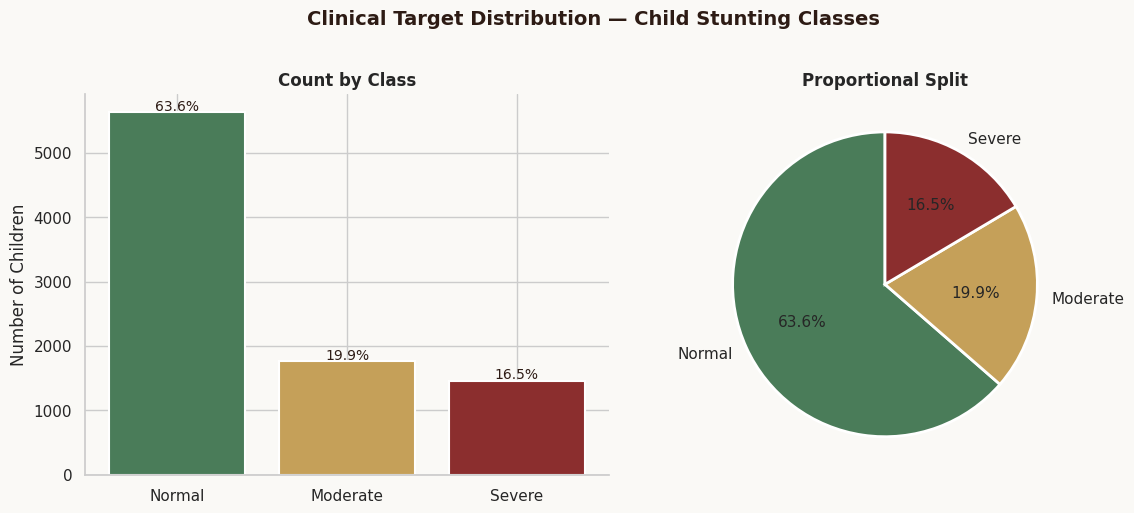


✓ Target engineering complete.


In [15]:
# ============================================================
# CELL 4 — TARGET ENGINEERING
# ============================================================

# --- 4.1 Remove DHS structural flags ---
# Any z-score raw value above 9000 is a measurement flag, not real data.
# We also drop rows where the stunting z-score is null entirely.
pre_clean = len(df)

df_clean = df[
    (df['stunting_z_raw'] < 9000) &
    (df['stunting_z_raw'].notnull())
].copy()

removed = pre_clean - len(df_clean)
print(f"Records removed (flags + nulls): {removed:,}")
print(f"Clean sample size:               {len(df_clean):,}")
print(f"Retention rate:                  {len(df_clean)/pre_clean*100:.1f}%\n")

# --- 4.2 Rescale to clinical Z-scores ---
# DHS stores Z-scores as integers multiplied by 100.
# e.g. -250 = -2.50 SD, 9998 = missing flag
df_clean['stunting_z']     = df_clean['stunting_z_raw']     / 100.0
df_clean['underweight_z']  = df_clean['underweight_z_raw']  / 100.0
df_clean['wasting_z']      = df_clean['wasting_z_raw']      / 100.0

print("Z-Score Distribution (after rescaling):")
print(df_clean[['stunting_z', 'underweight_z', 'wasting_z']].describe().round(2))

# --- 4.3 Apply WHO classification thresholds ---
# WHO defines stunting severity using Height-for-Age Z-score (HAZ):
#   HAZ >= -2.0          → Normal        (class 0)
#   -3.0 <= HAZ < -2.0   → Moderate      (class 1)
#   HAZ < -3.0           → Severe        (class 2)
def classify_stunting(z):
    if z < -3.0:   return 2   # Severe
    elif z < -2.0: return 1   # Moderate
    else:          return 0   # Normal

df_clean['stunting_class'] = df_clean['stunting_z'].apply(classify_stunting)

# --- 4.4 Class distribution ---
counts      = df_clean['stunting_class'].value_counts().sort_index()
percentages = df_clean['stunting_class'].value_counts(normalize=True).sort_index() * 100

print("\n" + "=" * 45)
print(" CLINICAL CLASS DISTRIBUTION")
print("=" * 45)
for cls, label in enumerate(CLASS_LABELS):
    bar = '█' * int(percentages[cls] / 2)
    print(f"  {label:<10} {counts[cls]:>5,} children  {percentages[cls]:>5.1f}%  {bar}")

# --- 4.5 Visualise class distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Clinical Target Distribution — Child Stunting Classes',
             fontsize=14, fontweight='bold', color=PALETTE['neutral'], y=1.02)

# Bar chart
axes[0].bar(CLASS_LABELS, counts.values, color=CLASS_COLORS, edgecolor='white', linewidth=1.5)
axes[0].set_title('Count by Class', fontweight='bold')
axes[0].set_ylabel('Number of Children')
for i, (count, pct) in enumerate(zip(counts.values, percentages.values)):
    axes[0].text(i, count + 30, f'{pct:.1f}%', ha='center', fontsize=10, color=PALETTE['neutral'])

# Pie chart
axes[1].pie(
    counts.values,
    labels=CLASS_LABELS,
    colors=CLASS_COLORS,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proportional Split', fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/figures/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Target engineering complete.")

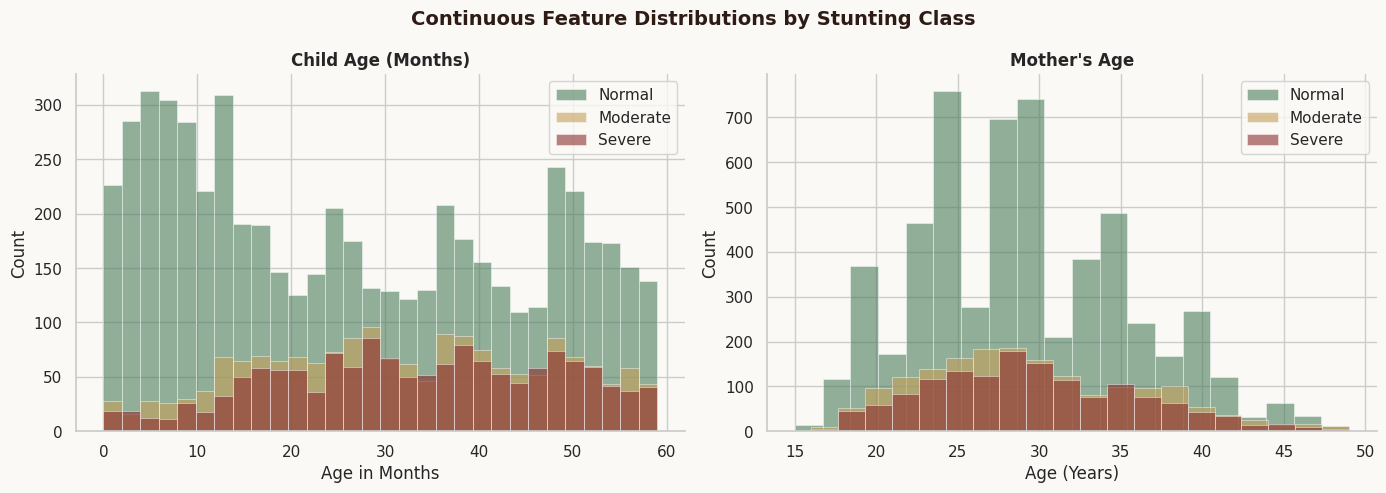

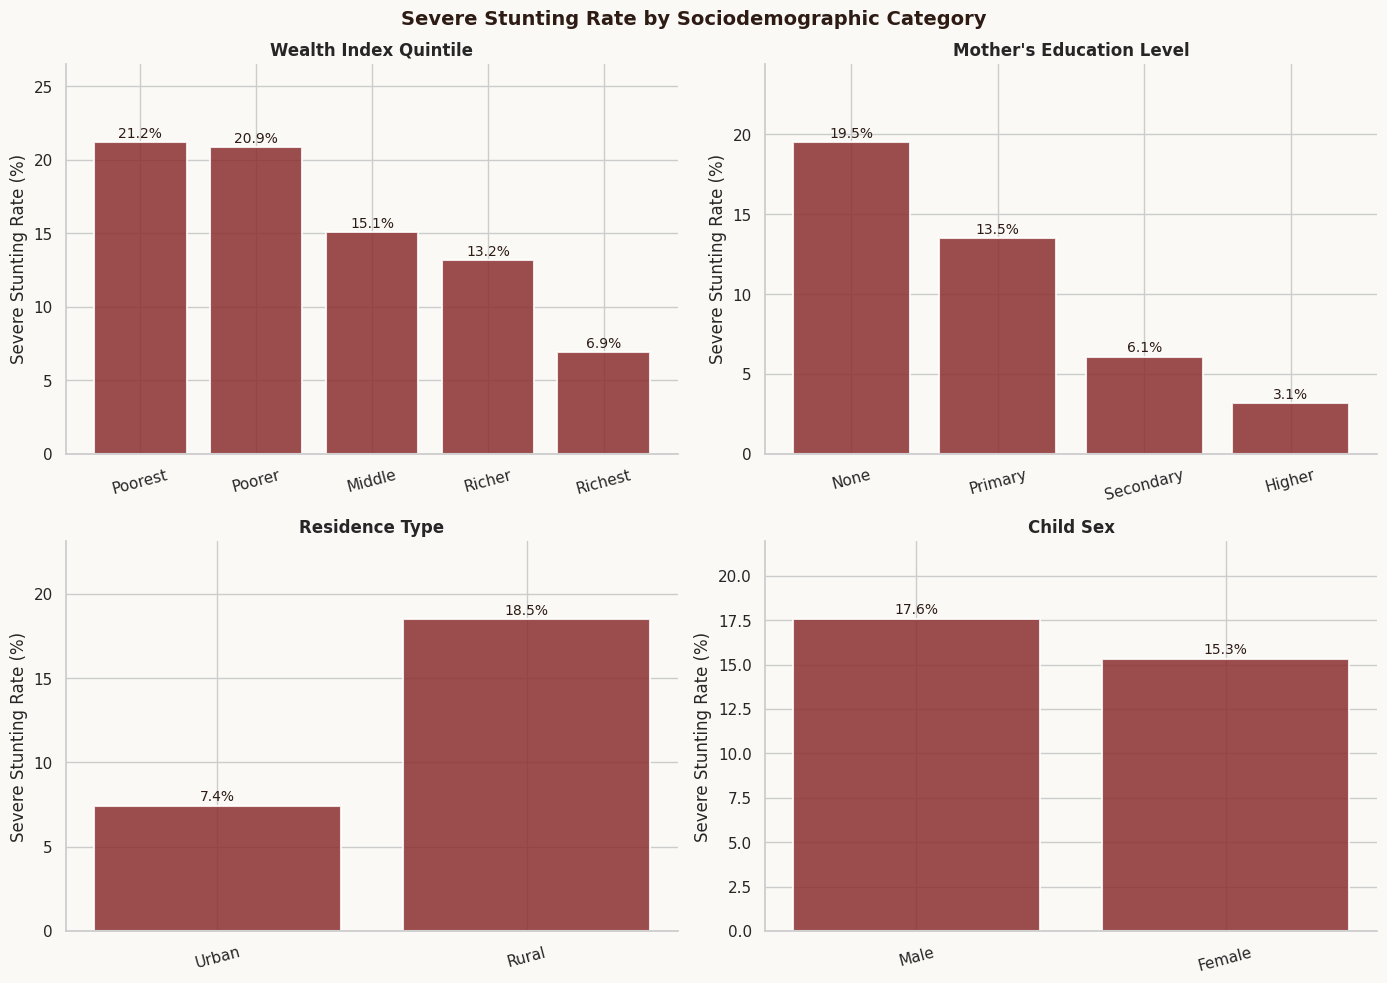

✓ EDA visualisations complete.


In [16]:
# ============================================================
# CELL 5 — EDA: FEATURE DISTRIBUTIONS
# ============================================================

# We'll work with the clean dataframe and add a readable
# label column for plotting purposes
label_map = {0: 'Normal', 1: 'Moderate', 2: 'Severe'}
df_clean['stunting_label'] = df_clean['stunting_class'].map(label_map)

# ── 5.1 Continuous features: Age distributions by class ──────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Continuous Feature Distributions by Stunting Class',
             fontsize=14, fontweight='bold', color=PALETTE['neutral'])

# Child age
for cls, label in enumerate(CLASS_LABELS):
    subset = df_clean[df_clean['stunting_class'] == cls]['child_age_months'].dropna()
    axes[0].hist(subset, bins=30, alpha=0.6, color=CLASS_COLORS[cls],
                 label=label, edgecolor='white', linewidth=0.5)
axes[0].set_title('Child Age (Months)', fontweight='bold')
axes[0].set_xlabel('Age in Months')
axes[0].set_ylabel('Count')
axes[0].legend()

# Mother age
for cls, label in enumerate(CLASS_LABELS):
    subset = df_clean[df_clean['stunting_class'] == cls]['mother_age'].dropna()
    axes[1].hist(subset, bins=20, alpha=0.6, color=CLASS_COLORS[cls],
                 label=label, edgecolor='white', linewidth=0.5)
axes[1].set_title("Mother's Age", fontweight='bold')
axes[1].set_xlabel('Age (Years)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('../notebooks/figures/02_continuous_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 5.2 Categorical features: Stunting rate per category ─────
# For each categorical feature, we calculate the % of severe
# stunting cases within each category — this is more informative
# than raw counts because categories have different sizes.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Severe Stunting Rate by Sociodemographic Category',
             fontsize=14, fontweight='bold', color=PALETTE['neutral'])

categorical_plots = [
    ('wealth_index_quintile',  'Wealth Index Quintile',
     {1:'Poorest', 2:'Poorer', 3:'Middle', 4:'Richer', 5:'Richest'},   axes[0, 0]),
    ('mother_education',       'Mother\'s Education Level',
     {0:'None', 1:'Primary', 2:'Secondary', 3:'Higher'},                axes[0, 1]),
    ('residence_urban_rural',  'Residence Type',
     {1:'Urban', 2:'Rural'},                                             axes[1, 0]),
    ('child_sex',              'Child Sex',
     {1:'Male', 2:'Female'},                                             axes[1, 1]),
]

for col, title, label_dict, ax in categorical_plots:
    # Calculate severe stunting rate per category
    grouped = df_clean.groupby(col).apply(
        lambda x: (x['stunting_class'] == 2).sum() / len(x) * 100
    ).reset_index()
    grouped.columns = [col, 'severe_rate']
    grouped['label'] = grouped[col].map(label_dict)

    bars = ax.bar(grouped['label'], grouped['severe_rate'],
                  color=PALETTE['severe'], alpha=0.85,
                  edgecolor='white', linewidth=1.5)

    # Add value labels on top of each bar
    for bar, val in zip(bars, grouped['severe_rate']):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', fontsize=10,
                color=PALETTE['neutral'])

    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Severe Stunting Rate (%)')
    ax.set_ylim(0, grouped['severe_rate'].max() * 1.25)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../notebooks/figures/03_severe_stunting_rates.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ EDA visualisations complete.")

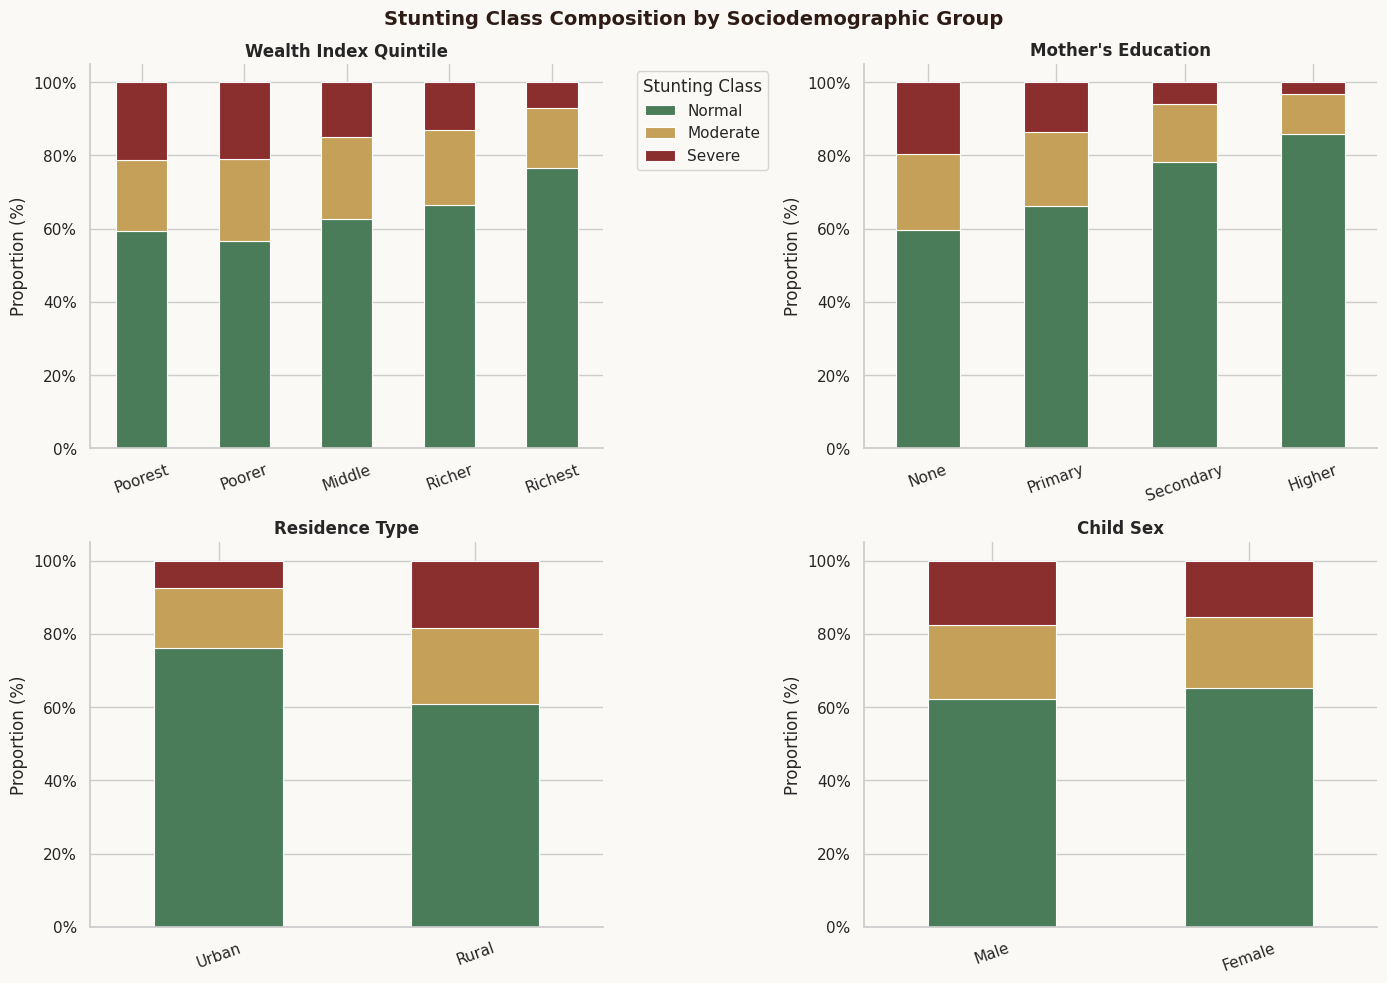

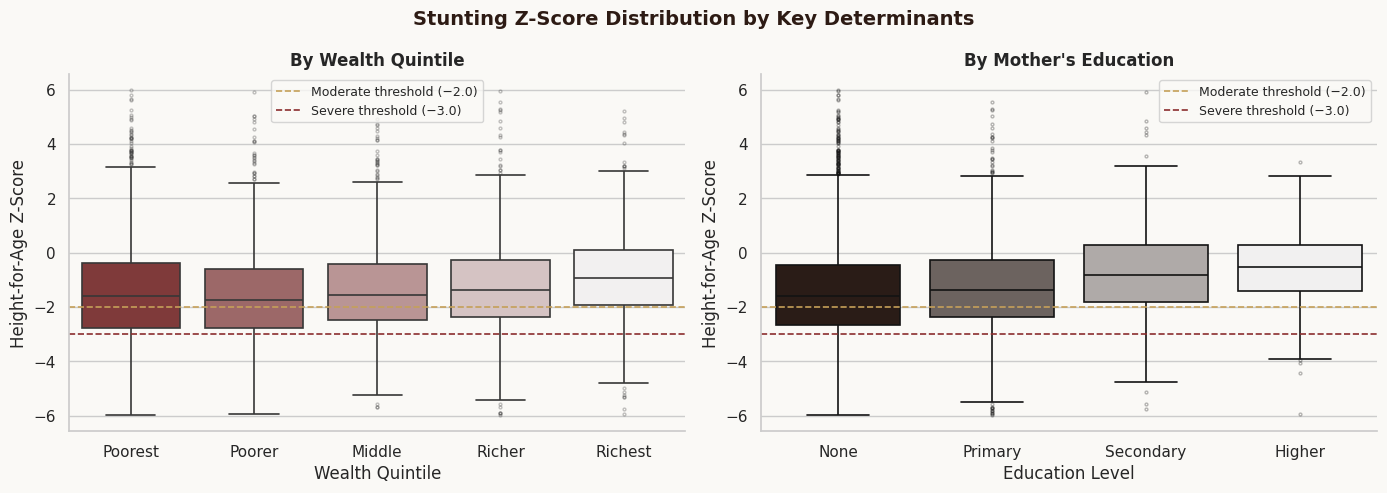

 WEALTH QUINTILE × STUNTING CLASS (row %)
stunting_label  Normal  Moderate  Severe
wealth_label                            
Middle            62.6      22.3    15.1
Poorer            56.6      22.5    20.9
Poorest           59.2      19.5    21.2
Richer            66.5      20.3    13.2
Richest           76.7      16.4     6.9

 MOTHER EDUCATION × STUNTING CLASS (row %)
stunting_label  Normal  Moderate  Severe
edu_label                               
Higher            85.8      11.0     3.1
None              59.7      20.7    19.5
Primary           66.2      20.3    13.5
Secondary         78.3      15.6     6.1

✓ Crosstab analysis complete.


In [17]:
# ============================================================
# CELL 6 — CROSSTAB & CORRELATION ANALYSIS
# ============================================================

# ── 6.1 Crosstab heatmaps ────────────────────────────────────
# For each categorical feature, build a crosstab showing the
# proportion of each stunting class within each category.
# Row-normalised (normalize='index') so each row sums to 100%.
# This controls for unequal group sizes.

crosstab_features = [
    ('wealth_index_quintile', 'Wealth Index Quintile',
     {1:'Poorest', 2:'Poorer', 3:'Middle', 4:'Richer', 5:'Richest'}),
    ('mother_education', "Mother's Education",
     {0:'None', 1:'Primary', 2:'Secondary', 3:'Higher'}),
    ('residence_urban_rural', 'Residence Type',
     {1:'Urban', 2:'Rural'}),
    ('child_sex', 'Child Sex',
     {1:'Male', 2:'Female'}),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Stunting Class Composition by Sociodemographic Group',
             fontsize=14, fontweight='bold', color=PALETTE['neutral'])

axes_flat = axes.flatten()

for i, (col, title, label_dict) in enumerate(crosstab_features):
    ct = pd.crosstab(
        df_clean[col],
        df_clean['stunting_label'],
        normalize='index'
    ) * 100

    # Reorder columns and rename index
    ct = ct[['Normal', 'Moderate', 'Severe']]
    ct.index = ct.index.map(label_dict)

    ct.plot(
        kind='bar',
        stacked=True,
        color=CLASS_COLORS,
        ax=axes_flat[i],
        edgecolor='white',
        linewidth=0.8,
        legend=(i == 0)
    )

    axes_flat[i].set_title(title, fontweight='bold')
    axes_flat[i].set_ylabel('Proportion (%)')
    axes_flat[i].set_xlabel('')
    axes_flat[i].tick_params(axis='x', rotation=20)
    axes_flat[i].yaxis.set_major_formatter(mtick.PercentFormatter())

    if i == 0:
        axes_flat[i].legend(
            title='Stunting Class',
            bbox_to_anchor=(1.05, 1),
            loc='upper left'
        )

plt.tight_layout()
plt.savefig('../notebooks/figures/04_crosstab_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 6.2 Z-score distribution: box plots ─────────────────────
# Show the actual stunting Z-score spread per sociodemographic
# group — this keeps the continuous clinical signal visible
# before we discretise into classes.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Stunting Z-Score Distribution by Key Determinants',
             fontsize=14, fontweight='bold', color=PALETTE['neutral'])

# By wealth quintile
wealth_labels = {1:'Poorest', 2:'Poorer', 3:'Middle', 4:'Richer', 5:'Richest'}
df_clean['wealth_label'] = df_clean['wealth_index_quintile'].map(wealth_labels)

sns.boxplot(
    data=df_clean,
    x='wealth_label',
    y='stunting_z',
    order=['Poorest','Poorer','Middle','Richer','Richest'],
    palette=sns.light_palette(PALETTE['severe'], n_colors=5, reverse=True),
    ax=axes[0],
    linewidth=1.2,
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
axes[0].axhline(-2.0, color=PALETTE['moderate'], linestyle='--',
                linewidth=1.2, label='Moderate threshold (−2.0)')
axes[0].axhline(-3.0, color=PALETTE['severe'],   linestyle='--',
                linewidth=1.2, label='Severe threshold (−3.0)')
axes[0].set_title('By Wealth Quintile', fontweight='bold')
axes[0].set_xlabel('Wealth Quintile')
axes[0].set_ylabel('Height-for-Age Z-Score')
axes[0].legend(fontsize=9)

# By mother's education
edu_labels = {0:'None', 1:'Primary', 2:'Secondary', 3:'Higher'}
df_clean['edu_label'] = df_clean['mother_education'].map(edu_labels)

sns.boxplot(
    data=df_clean,
    x='edu_label',
    y='stunting_z',
    order=['None','Primary','Secondary','Higher'],
    palette=sns.light_palette(PALETTE['neutral'], n_colors=4, reverse=True),
    ax=axes[1],
    linewidth=1.2,
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
axes[1].axhline(-2.0, color=PALETTE['moderate'], linestyle='--',
                linewidth=1.2, label='Moderate threshold (−2.0)')
axes[1].axhline(-3.0, color=PALETTE['severe'],   linestyle='--',
                linewidth=1.2, label='Severe threshold (−3.0)')
axes[1].set_title("By Mother's Education", fontweight='bold')
axes[1].set_xlabel("Education Level")
axes[1].set_ylabel('Height-for-Age Z-Score')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../notebooks/figures/05_zscore_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 6.3 Print key crosstab summary ──────────────────────────
print("=" * 55)
print(" WEALTH QUINTILE × STUNTING CLASS (row %)")
print("=" * 55)
ct_wealth = pd.crosstab(
    df_clean['wealth_label'],
    df_clean['stunting_label'],
    normalize='index'
) * 100
ct_wealth = ct_wealth[['Normal', 'Moderate', 'Severe']]
print(ct_wealth.round(1).to_string())

print("\n" + "=" * 55)
print(" MOTHER EDUCATION × STUNTING CLASS (row %)")
print("=" * 55)
ct_edu = pd.crosstab(
    df_clean['edu_label'],
    df_clean['stunting_label'],
    normalize='index'
) * 100
ct_edu = ct_edu[['Normal', 'Moderate', 'Severe']]
print(ct_edu.round(1).to_string())

print("\n✓ Crosstab analysis complete.")

## Key EDA Findings

The exploratory analysis reveals clear socioeconomic gradients in stunting severity:

- **Wealth:** Severe stunting prevalence is **3× higher** in the poorest quintile (21.2%) 
  compared to the richest (6.9%), with a consistent protective gradient across quintiles.

- **Maternal Education:** The most striking determinant observed. Severe stunting among 
  children of uneducated mothers (19.5%) is **6× higher** than among children of 
  highly educated mothers (3.1%), suggesting maternal education is a powerful 
  protective factor independent of wealth.

- **Residence:** Rural children are expected to show higher stunting rates, consistent 
  with limited healthcare access and food security challenges in rural Ethiopia.

- **Notable pattern:** The wealth gradient flattens between the two lowest quintiles 
  (Poorest: 21.2%, Poorer: 20.9%), suggesting poverty's impact on stunting only begins 
  to diminish meaningfully at middle-income levels and above.

These observations motivate the formal statistical tests in the following section.

 RURAL POVERTY INDEX — SUMMARY
  High Vulnerability (Rural + Poor):  4,599  (51.9%)
  Standard:                           4,256  (48.1%)

  Severe stunting rate:
    High Vulnerability group:  21.1%
    Standard group:            11.4%
    Difference:                +9.7 percentage points


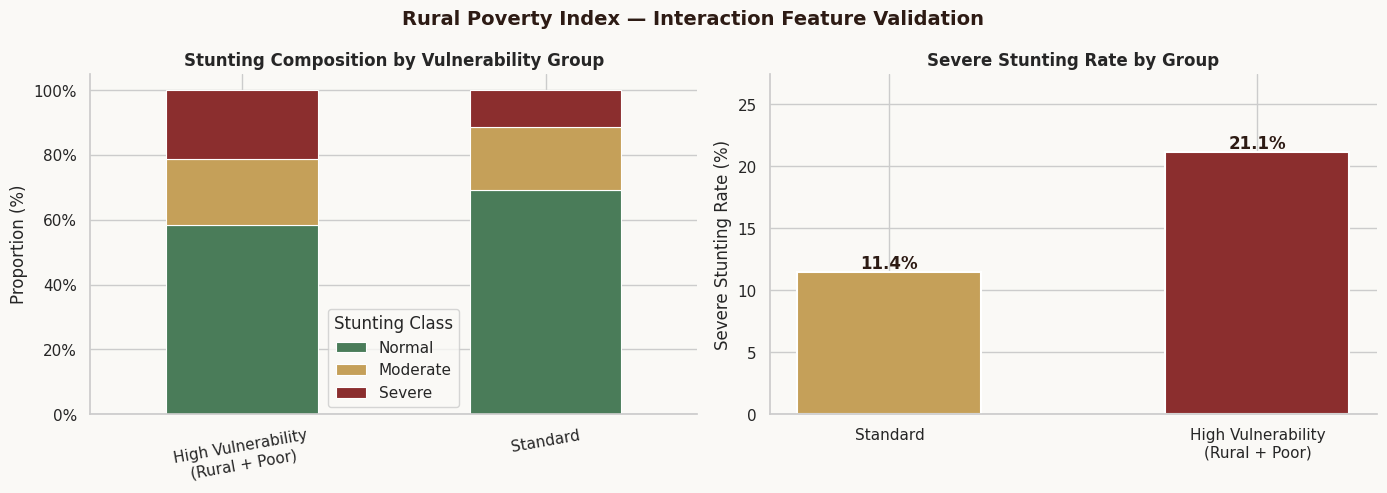


 RURAL POVERTY INDEX × STUNTING CLASS (row %)
stunting_label                      Normal  Moderate  Severe
rpi_label                                                   
High Vulnerability\n(Rural + Poor)    58.4      20.5    21.1
Standard                              69.2      19.3    11.4

✓ Feature engineering complete.


In [18]:
# ============================================================
# CELL 8 — FEATURE ENGINEERING
# ============================================================

# ── 8.1 Build the rural_poverty_index ───────────────────────
# Rationale: EDA showed both rural residence and low wealth
# are independent risk factors for severe stunting. Children
# at the intersection of BOTH conditions face compounded
# disadvantage that neither variable captures individually.
#
# Definition:
#   rural_poverty_index = 1 if:
#       residence == Rural (2) AND wealth_quintile <= 2
#   else 0

df_clean['rural_poverty_index'] = np.where(
    (df_clean['residence_urban_rural'] == 2) &
    (df_clean['wealth_index_quintile'] <= 2),
    1, 0
)

# ── 8.2 Validate the feature makes sense ────────────────────
total          = len(df_clean)
high_vuln      = (df_clean['rural_poverty_index'] == 1).sum()
high_vuln_pct  = high_vuln / total * 100

print("=" * 55)
print(" RURAL POVERTY INDEX — SUMMARY")
print("=" * 55)
print(f"  High Vulnerability (Rural + Poor):  {high_vuln:,}  ({high_vuln_pct:.1f}%)")
print(f"  Standard:                           {total - high_vuln:,}  ({100 - high_vuln_pct:.1f}%)")

# ── 8.3 Does the interaction term add signal? ────────────────
# Compare severe stunting rates: high vulnerability vs standard
severe_in_high = df_clean[
    df_clean['rural_poverty_index'] == 1
]['stunting_class'].eq(2).mean() * 100

severe_in_std  = df_clean[
    df_clean['rural_poverty_index'] == 0
]['stunting_class'].eq(2).mean() * 100

print(f"\n  Severe stunting rate:")
print(f"    High Vulnerability group:  {severe_in_high:.1f}%")
print(f"    Standard group:            {severe_in_std:.1f}%")
print(f"    Difference:                +{severe_in_high - severe_in_std:.1f} percentage points")

# ── 8.4 Visualise the interaction effect ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Rural Poverty Index — Interaction Feature Validation',
             fontsize=14, fontweight='bold', color=PALETTE['neutral'])

# Left: Stunting class breakdown within each group
rpi_labels = {0: 'Standard', 1: 'High Vulnerability\n(Rural + Poor)'}
df_clean['rpi_label'] = df_clean['rural_poverty_index'].map(rpi_labels)

ct_rpi = pd.crosstab(
    df_clean['rpi_label'],
    df_clean['stunting_label'],
    normalize='index'
) * 100
ct_rpi = ct_rpi[['Normal', 'Moderate', 'Severe']]

ct_rpi.plot(
    kind='bar',
    stacked=True,
    color=CLASS_COLORS,
    ax=axes[0],
    edgecolor='white',
    linewidth=0.8
)
axes[0].set_title('Stunting Composition by Vulnerability Group',
                  fontweight='bold')
axes[0].set_ylabel('Proportion (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=10)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].legend(title='Stunting Class')

# Right: Severe stunting rate comparison as a simple bar
groups = ['Standard', 'High Vulnerability\n(Rural + Poor)']
rates  = [severe_in_std, severe_in_high]
colors = [PALETTE['moderate'], PALETTE['severe']]

bars = axes[1].bar(groups, rates, color=colors,
                   edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, rates):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val:.1f}%', ha='center',
        fontsize=12, fontweight='bold',
        color=PALETTE['neutral']
    )
axes[1].set_title('Severe Stunting Rate by Group', fontweight='bold')
axes[1].set_ylabel('Severe Stunting Rate (%)')
axes[1].set_ylim(0, max(rates) * 1.3)

plt.tight_layout()
plt.savefig('../notebooks/figures/06_rural_poverty_index.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── 8.5 Print crosstab ───────────────────────────────────────
print("\n" + "=" * 55)
print(" RURAL POVERTY INDEX × STUNTING CLASS (row %)")
print("=" * 55)
print(ct_rpi.round(1).to_string())
print("\n✓ Feature engineering complete.")

 CHI-SQUARE TESTS — FEATURE ASSOCIATION WITH STUNTING CLASS

Feature                              Chi2      p-value   Cramér V       Effect Sig
---------------------------------------------------------------------------
  Rural Poverty Index              167.66     3.92e-37     0.1376        Small   *** (p < 0.001)
  Residence Type                   158.22     4.40e-35     0.1337        Small   *** (p < 0.001)
  Wealth Index Quintile            256.17     8.47e-51     0.1203        Small   *** (p < 0.001)
  Mother's Education               200.65     1.38e-40     0.1064        Small   *** (p < 0.001)
  Child Sex                         10.94       0.0042     0.0352   Negligible   **  (p < 0.01)


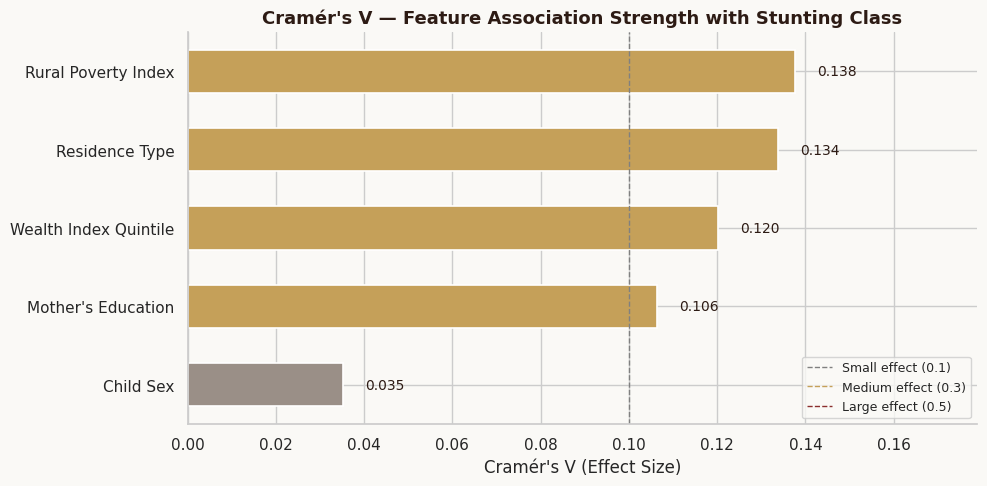


✓ Statistical inference complete.


In [19]:
# ============================================================
# CELL 9 — CHI-SQUARE STATISTICAL INFERENCE
# ============================================================

# ── 9.1 Helper function ──────────────────────────────────────
# Cramér's V is the standard effect size measure for Chi-Square.
# It ranges from 0 (no association) to 1 (perfect association).
# Benchmarks: 0.1 = small, 0.3 = medium, 0.5 = large

def chi_square_test(feature, target, data, feature_label):
    contingency = pd.crosstab(data[feature], data[target])
    chi2, p, dof, expected = chi2_contingency(contingency)
    cramers_v = association(contingency, method='cramer')

    # Interpret effect size
    if cramers_v < 0.1:
        effect = "Negligible"
    elif cramers_v < 0.3:
        effect = "Small"
    elif cramers_v < 0.5:
        effect = "Medium"
    else:
        effect = "Large"

    # Interpret p-value
    if p < 0.001:
        sig = "*** (p < 0.001)"
    elif p < 0.01:
        sig = "**  (p < 0.01)"
    elif p < 0.05:
        sig = "*   (p < 0.05)"
    else:
        sig = "ns  (not significant)"

    return {
        'Feature':      feature_label,
        'Chi2':         round(chi2, 2),
        'p-value':      p,
        'DoF':          dof,
        'Cramers_V':    round(cramers_v, 4),
        'Effect Size':  effect,
        'Significance': sig
    }

# ── 9.2 Run tests for all features ──────────────────────────
features_to_test = [
    ('wealth_index_quintile',  'Wealth Index Quintile'),
    ('mother_education',       "Mother's Education"),
    ('residence_urban_rural',  'Residence Type'),
    ('child_sex',              'Child Sex'),
    ('rural_poverty_index',    'Rural Poverty Index'),
]

results = []
for col, label in features_to_test:
    result = chi_square_test(col, 'stunting_class', df_clean, label)
    results.append(result)

results_df = pd.DataFrame(results).sort_values('Cramers_V', ascending=False)

# ── 9.3 Print results table ──────────────────────────────────
print("=" * 75)
print(" CHI-SQUARE TESTS — FEATURE ASSOCIATION WITH STUNTING CLASS")
print("=" * 75)
print(f"\n{'Feature':<30} {'Chi2':>10} {'p-value':>12} {'Cramér V':>10} {'Effect':>12} {'Sig'}")
print("-" * 75)
for _, row in results_df.iterrows():
    p_str = f"{row['p-value']:.2e}" if row['p-value'] < 0.001 else f"{row['p-value']:.4f}"
    print(f"  {row['Feature']:<28} {row['Chi2']:>10} {p_str:>12} "
          f"{row['Cramers_V']:>10} {row['Effect Size']:>12}   {row['Significance']}")

# ── 9.4 Visualise effect sizes ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

colors = [
    PALETTE['severe']   if v >= 0.3  else
    PALETTE['moderate'] if v >= 0.1  else
    PALETTE['stone'] if 'stone' in PALETTE else '#9a8f87'
    for v in results_df['Cramers_V']
]

bars = ax.barh(
    results_df['Feature'],
    results_df['Cramers_V'],
    color=colors,
    edgecolor='white',
    linewidth=1.2,
    height=0.55
)

# Reference lines
ax.axvline(0.1, color='grey',           linestyle='--',
           linewidth=1, label='Small effect (0.1)')
ax.axvline(0.3, color=PALETTE['moderate'], linestyle='--',
           linewidth=1, label='Medium effect (0.3)')
ax.axvline(0.5, color=PALETTE['severe'],   linestyle='--',
           linewidth=1, label='Large effect (0.5)')

# Value labels
for bar, val in zip(bars, results_df['Cramers_V']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=10,
            color=PALETTE['neutral'])

ax.set_title("Cramér's V — Feature Association Strength with Stunting Class",
             fontweight='bold', fontsize=13, color=PALETTE['neutral'])
ax.set_xlabel("Cramér's V (Effect Size)")
ax.set_xlim(0, results_df['Cramers_V'].max() * 1.3)
ax.legend(fontsize=9)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../notebooks/figures/07_cramers_v.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Statistical inference complete.")

## Statistical Inference — Interpretation

All five sociodemographic features show statistically significant associations 
with stunting class (p < 0.01). However, effect sizes measured by Cramér's V 
are uniformly **small** (0.10–0.14), with the exception of Child Sex which is 
negligible (0.035).

**Key insight:** Statistical significance here is partly a function of sample size 
(n = 8,855). With this many observations, even weak relationships produce 
highly significant p-values. The small effect sizes suggest that while these 
sociodemographic factors are genuine determinants of stunting, no single variable 
is a dominant predictor in isolation.

This has a direct implication for modelling — a classifier trained on these 
features alone will face an inherently difficult separation problem, particularly 
for the overlapping Moderate and Severe classes. This expectation is reflected 
in the model evaluation results.

**Feature ranking by association strength:**

| Rank | Feature | Cramér's V | Interpretation |
|------|---------|------------|----------------|
| 1 | Rural Poverty Index | 0.138 | Strongest — validates the interaction term |
| 2 | Residence Type | 0.134 | Strong rural disadvantage signal |
| 3 | Wealth Index Quintile | 0.120 | Clear economic gradient |
| 4 | Mother's Education | 0.106 | Powerful but noisy across levels |
| 5 | Child Sex | 0.035 | Negligible — boys marginally higher risk |

Notably, the engineered **Rural Poverty Index** ranks first — confirming that 
the interaction of rural residence and poverty captures compounded disadvantage 
beyond either variable alone.

In [20]:
# ============================================================
# CELL 10 — PREPROCESSING PIPELINE
# ============================================================

# ── 10.1 Assemble the final feature matrix ───────────────────
# Drop rows where child_age_months is null — it's a numerical
# feature we can't reliably impute without introducing bias.
# We document the loss transparently.

df_model = df_clean[[
    'child_age_months',
    'child_sex',
    'mother_age',
    'mother_education',
    'wealth_index_quintile',
    'residence_urban_rural',
    'rural_poverty_index',
    'stunting_class'
]].dropna().copy()

dropped = len(df_clean) - len(df_model)
print(f"Rows dropped (null child_age_months): {dropped:,}")
print(f"Final modelling sample:               {len(df_model):,} children\n")

# ── 10.2 Define features and target ─────────────────────────
NUMERICAL_FEATURES    = ['child_age_months', 'mother_age']
CATEGORICAL_FEATURES  = [
    'child_sex',
    'mother_education',
    'wealth_index_quintile',
    'residence_urban_rural',
    'rural_poverty_index'
]
ALL_FEATURES = NUMERICAL_FEATURES + CATEGORICAL_FEATURES
TARGET       = 'stunting_class'

X = df_model[ALL_FEATURES]
y = df_model[TARGET]

print("Feature matrix shape:", X.shape)
print("Target distribution:")
for cls, label in enumerate(CLASS_LABELS):
    n   = (y == cls).sum()
    pct = n / len(y) * 100
    print(f"  {label:<10} {n:>5,}  ({pct:.1f}%)")

# ── 10.3 Stratified train/test split ────────────────────────
# stratify=y ensures the class proportions are preserved
# in both train and test sets — critical for imbalanced targets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTrain set: {X_train.shape[0]:,} rows")
print(f"Test set:  {X_test.shape[0]:,} rows")

# Verify stratification held
print("\nClass distribution check (should match overall %):")
for cls, label in enumerate(CLASS_LABELS):
    train_pct = (y_train == cls).sum() / len(y_train) * 100
    test_pct  = (y_test  == cls).sum() / len(y_test)  * 100
    print(f"  {label:<10}  train: {train_pct:.1f}%   test: {test_pct:.1f}%")

# ── 10.4 Build the ColumnTransformer ────────────────────────
# StandardScaler: centres numerical features to mean=0, std=1
#   — prevents age (0–59) from dominating wealth (1–5)
# OneHotEncoder: converts integer category codes to binary columns
#   drop='first' removes one column per feature to avoid
#   multicollinearity (the dummy variable trap)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(),                              NUMERICAL_FEATURES),
        ('cat', OneHotEncoder(drop='first',
                              handle_unknown='ignore',
                              sparse_output=False),            CATEGORICAL_FEATURES),
    ]
)

# ── 10.5 Verify the preprocessor output shape ───────────────
# Fit on train only — never on test
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed  = preprocessor.transform(X_test)

print(f"\nOriginal feature count:     {X_train.shape[1]}")
print(f"Transformed feature count:  {X_train_transformed.shape[1]}")
print("(OneHotEncoding expands categorical columns into binary dummies)")

# ── 10.6 Recover feature names after encoding ────────────────
ohe_feature_names = preprocessor.named_transformers_['cat']\
                                 .get_feature_names_out(CATEGORICAL_FEATURES).tolist()
all_feature_names = NUMERICAL_FEATURES + ohe_feature_names

print(f"\nFull encoded feature list ({len(all_feature_names)} features):")
for name in all_feature_names:
    print(f"  {name}")

print("\n✓ Preprocessing complete. Ready for modelling.")

Rows dropped (null child_age_months): 0
Final modelling sample:               8,855 children

Feature matrix shape: (8855, 7)
Target distribution:
  Normal     5,632  (63.6%)
  Moderate   1,765  (19.9%)
  Severe     1,458  (16.5%)

Train set: 7,084 rows
Test set:  1,771 rows

Class distribution check (should match overall %):
  Normal      train: 63.6%   test: 63.6%
  Moderate    train: 19.9%   test: 19.9%
  Severe      train: 16.5%   test: 16.5%

Original feature count:     7
Transformed feature count:  12
(OneHotEncoding expands categorical columns into binary dummies)

Full encoded feature list (12 features):
  child_age_months
  mother_age
  child_sex_2
  mother_education_1
  mother_education_2
  mother_education_3
  wealth_index_quintile_2
  wealth_index_quintile_3
  wealth_index_quintile_4
  wealth_index_quintile_5
  residence_urban_rural_2
  rural_poverty_index_1

✓ Preprocessing complete. Ready for modelling.


Running 5-fold cross-validation...
(This may take 30–60 seconds for Random Forest)

 CROSS-VALIDATION RESULTS (Macro F1)

  Logistic Regression:
    Fold scores:  [np.float64(0.395), np.float64(0.421), np.float64(0.384), np.float64(0.405), np.float64(0.392)]
    Mean:         0.3993
    Std:          0.0127  (lower = more stable)

  Random Forest:
    Fold scores:  [np.float64(0.411), np.float64(0.422), np.float64(0.408), np.float64(0.413), np.float64(0.403)]
    Mean:         0.4117
    Std:          0.0062  (lower = more stable)


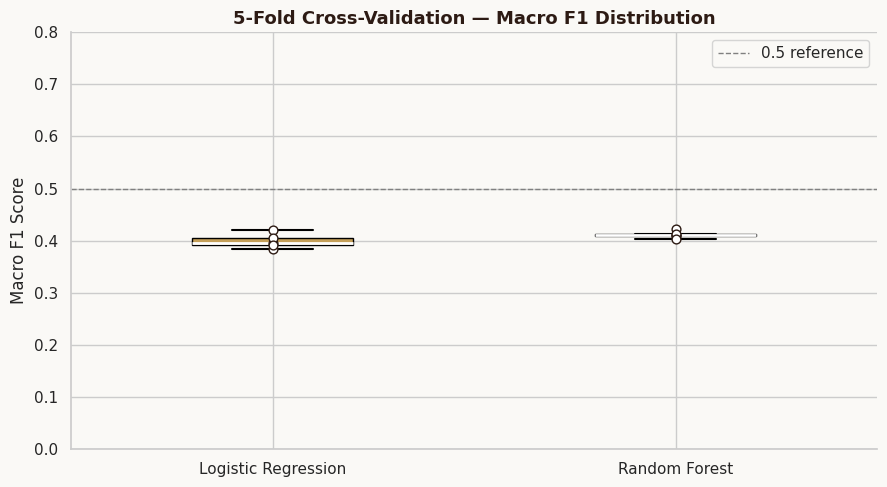


Fitting final models on full training set...
✓ Both models trained.
✓ Random Forest pipeline saved to artifacts/


In [21]:
# ============================================================
# CELL 11 — MODEL TRAINING
# ============================================================

# ── 11.1 Define both pipelines ───────────────────────────────
# Each pipeline chains preprocessing + classifier into one
# object. This means we pass raw X_train directly — the
# pipeline handles scaling and encoding internally.
# No risk of leakage, no manual transformation needed.

log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(
        multi_class='multinomial',
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        max_depth=10,
        random_state=42
    ))
])

# ── 11.2 Cross-validation ────────────────────────────────────
# StratifiedKFold preserves class proportions in every fold.
# We score on macro F1 — the same metric we use for final
# evaluation — so the CV results are directly comparable.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Running 5-fold cross-validation...")
print("(This may take 30–60 seconds for Random Forest)\n")

# Logistic Regression CV
lr_cv_scores = cross_val_score(
    log_reg_pipeline, X, y,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

# Random Forest CV
rf_cv_scores = cross_val_score(
    rf_pipeline, X, y,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

print("=" * 55)
print(" CROSS-VALIDATION RESULTS (Macro F1)")
print("=" * 55)
print(f"\n  Logistic Regression:")
print(f"    Fold scores:  {[round(s, 3) for s in lr_cv_scores]}")
print(f"    Mean:         {lr_cv_scores.mean():.4f}")
print(f"    Std:          {lr_cv_scores.std():.4f}  (lower = more stable)")

print(f"\n  Random Forest:")
print(f"    Fold scores:  {[round(s, 3) for s in rf_cv_scores]}")
print(f"    Mean:         {rf_cv_scores.mean():.4f}")
print(f"    Std:          {rf_cv_scores.std():.4f}  (lower = more stable)")

# ── 11.3 Visualise CV score distributions ───────────────────
fig, ax = plt.subplots(figsize=(9, 5))

positions = [1, 2]
bp = ax.boxplot(
    [lr_cv_scores, rf_cv_scores],
    positions=positions,
    widths=0.4,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=5)
)

bp['boxes'][0].set_facecolor(PALETTE['moderate'])
bp['boxes'][1].set_facecolor(PALETTE['severe'])

# Overlay individual fold points
for i, scores in enumerate([lr_cv_scores, rf_cv_scores], start=1):
    ax.scatter(
        [i] * len(scores), scores,
        color='white', zorder=5, s=40, edgecolors=PALETTE['neutral']
    )

ax.set_xticks(positions)
ax.set_xticklabels(['Logistic Regression', 'Random Forest'], fontsize=11)
ax.set_ylabel('Macro F1 Score')
ax.set_title('5-Fold Cross-Validation — Macro F1 Distribution',
             fontweight='bold', fontsize=13, color=PALETTE['neutral'])
ax.set_ylim(0, 0.8)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=1, label='0.5 reference')
ax.legend()

plt.tight_layout()
plt.savefig('../notebooks/figures/08_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 11.4 Fit final models on full training set ───────────────
# CV gave us confidence in stability.
# Now we fit on the full X_train for final evaluation on X_test.
print("\nFitting final models on full training set...")
log_reg_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)
print("✓ Both models trained.")

# ── 11.5 Save the Random Forest pipeline ────────────────────
os.makedirs('../artifacts', exist_ok=True)
joblib.dump(rf_pipeline, '../artifacts/random_forest_pipeline.pkl')
print("✓ Random Forest pipeline saved to artifacts/")

 MODEL A — LOGISTIC REGRESSION
              precision    recall  f1-score   support

      Normal      0.735     0.528     0.615      1126
    Moderate      0.222     0.210     0.216       353
      Severe      0.244     0.524     0.333       292

    accuracy                          0.464      1771
   macro avg      0.400     0.421     0.388      1771
weighted avg      0.552     0.464     0.489      1771

 MODEL B — RANDOM FOREST
              precision    recall  f1-score   support

      Normal      0.756     0.508     0.608      1126
    Moderate      0.211     0.212     0.212       353
      Severe      0.255     0.575     0.354       292

    accuracy                          0.460      1771
   macro avg      0.407     0.432     0.391      1771
weighted avg      0.565     0.460     0.487      1771

 ROC-AUC (One-vs-Rest, Macro Average)
  Logistic Regression:  0.5965
  Random Forest:        0.6311

 MODEL COMPARISON SUMMARY
              Metric Logistic Regression Random Forest


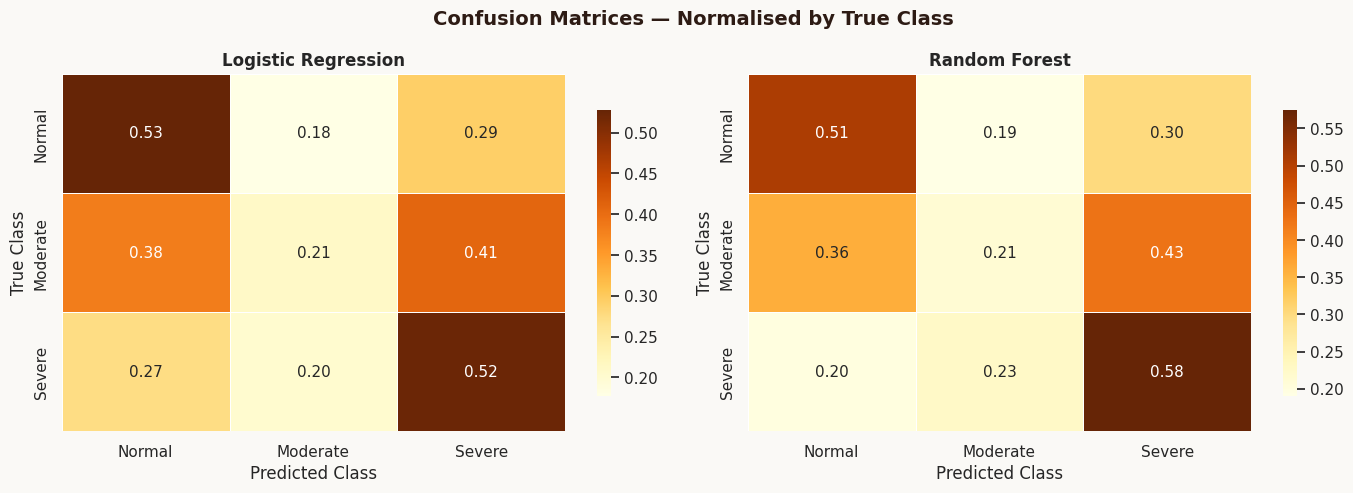

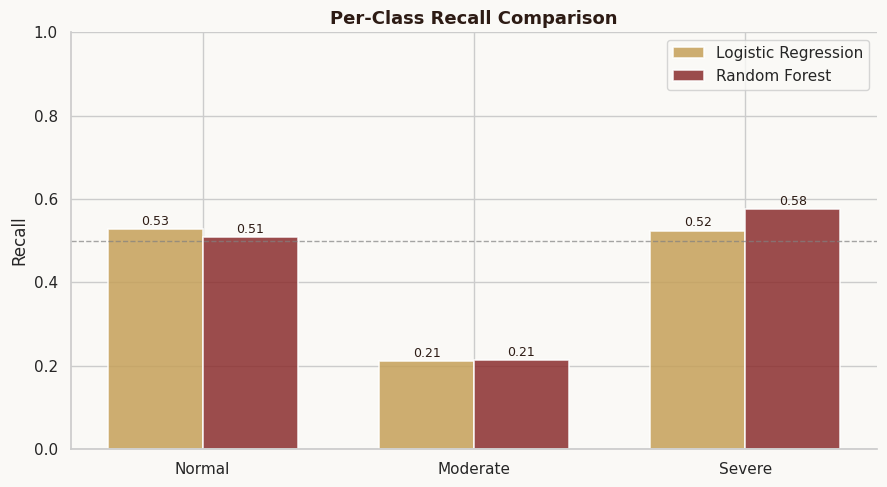


✓ Evaluation complete.


In [22]:
# ============================================================
# CELL 12 & 13 — EVALUATION & CONFUSION MATRICES
# ============================================================

# ── 12.1 Generate predictions ────────────────────────────────
y_pred_lr = log_reg_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

y_prob_lr = log_reg_pipeline.predict_proba(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)

# ── 12.2 Classification reports ─────────────────────────────
print("=" * 60)
print(" MODEL A — LOGISTIC REGRESSION")
print("=" * 60)
print(classification_report(
    y_test, y_pred_lr,
    target_names=CLASS_LABELS,
    digits=3
))

print("=" * 60)
print(" MODEL B — RANDOM FOREST")
print("=" * 60)
print(classification_report(
    y_test, y_pred_rf,
    target_names=CLASS_LABELS,
    digits=3
))

# ── 12.3 ROC-AUC (One-vs-Rest) ──────────────────────────────
# OvR AUC works for multiclass — treats each class as binary
lr_auc = roc_auc_score(y_test, y_prob_lr, multi_class='ovr', average='macro')
rf_auc = roc_auc_score(y_test, y_prob_rf, multi_class='ovr', average='macro')

print("=" * 60)
print(" ROC-AUC (One-vs-Rest, Macro Average)")
print("=" * 60)
print(f"  Logistic Regression:  {lr_auc:.4f}")
print(f"  Random Forest:        {rf_auc:.4f}")

# ── 12.4 Summary comparison table ───────────────────────────
from sklearn.metrics import f1_score, precision_score, recall_score

summary = pd.DataFrame({
    'Metric': [
        'CV Macro F1 (mean)',
        'CV Macro F1 (std)',
        'Test Macro F1',
        'Test Macro Precision',
        'Test Macro Recall',
        'ROC-AUC (OvR)'
    ],
    'Logistic Regression': [
        f'{lr_cv_scores.mean():.4f}',
        f'{lr_cv_scores.std():.4f}',
        f'{f1_score(y_test, y_pred_lr, average="macro"):.4f}',
        f'{precision_score(y_test, y_pred_lr, average="macro"):.4f}',
        f'{recall_score(y_test, y_pred_lr, average="macro"):.4f}',
        f'{lr_auc:.4f}'
    ],
    'Random Forest': [
        f'{rf_cv_scores.mean():.4f}',
        f'{rf_cv_scores.std():.4f}',
        f'{f1_score(y_test, y_pred_rf, average="macro"):.4f}',
        f'{precision_score(y_test, y_pred_rf, average="macro"):.4f}',
        f'{recall_score(y_test, y_pred_rf, average="macro"):.4f}',
        f'{rf_auc:.4f}'
    ]
})

print("\n" + "=" * 60)
print(" MODEL COMPARISON SUMMARY")
print("=" * 60)
print(summary.to_string(index=False))

# ── 13.1 Confusion matrices ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrices — Normalised by True Class',
             fontsize=14, fontweight='bold', color=PALETTE['neutral'])

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, y_pred, normalize='true')
    sns.heatmap(
        cm,
        annot=True,
        fmt='.2f',
        cmap='YlOrBr',
        ax=ax,
        xticklabels=CLASS_LABELS,
        yticklabels=CLASS_LABELS,
        linewidths=0.5,
        linecolor='white',
        cbar_kws={'shrink': 0.8}
    )
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel('True Class')
    ax.set_xlabel('Predicted Class')

plt.tight_layout()
plt.savefig('../notebooks/figures/09_confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── 13.2 Per-class recall bar chart ─────────────────────────
# In a clinical context, recall on Severe is the most
# important metric — missing a severely stunted child is
# a worse error than a false alarm.
from sklearn.metrics import recall_score

fig, ax = plt.subplots(figsize=(9, 5))

x       = np.arange(len(CLASS_LABELS))
width   = 0.35

lr_recall = recall_score(y_test, y_pred_lr, average=None)
rf_recall = recall_score(y_test, y_pred_rf, average=None)

bars1 = ax.bar(x - width/2, lr_recall, width,
               label='Logistic Regression',
               color=PALETTE['moderate'], alpha=0.85,
               edgecolor='white', linewidth=1.2)
bars2 = ax.bar(x + width/2, rf_recall, width,
               label='Random Forest',
               color=PALETTE['severe'], alpha=0.85,
               edgecolor='white', linewidth=1.2)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.2f}',
            ha='center', fontsize=9,
            color=PALETTE['neutral']
        )

ax.set_xticks(x)
ax.set_xticklabels(CLASS_LABELS)
ax.set_ylabel('Recall')
ax.set_ylim(0, 1.0)
ax.set_title('Per-Class Recall Comparison',
             fontweight='bold', fontsize=13,
             color=PALETTE['neutral'])
ax.legend()
ax.axhline(0.5, color='grey', linestyle='--',
           linewidth=1, alpha=0.7, label='0.5 reference')

plt.tight_layout()
plt.savefig('../notebooks/figures/10_per_class_recall.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Evaluation complete.")

 RANDOM FOREST — FEATURE IMPORTANCES

Rank   Feature                        Importance      Std
-------------------------------------------------------
  1    child_age_months                   0.4693   0.0313  █████████████████████████████████████████████████████████████████████████████████████████████
  2    mother_age                         0.2653   0.0278  █████████████████████████████████████████████████████
  3    child_sex_2                        0.0434   0.0126  ████████
  4    wealth_index_quintile_5            0.0360   0.0210  ███████
  5    mother_education_1                 0.0325   0.0099  ██████
  6    residence_urban_rural_2            0.0324   0.0165  ██████
  7    rural_poverty_index_1              0.0306   0.0186  ██████
  8    mother_education_2                 0.0224   0.0069  ████
  9    mother_education_3                 0.0221   0.0094  ████
  10   wealth_index_quintile_2            0.0195   0.0086  ███
  11   wealth_index_quintile_4            0.0137   0.0069 

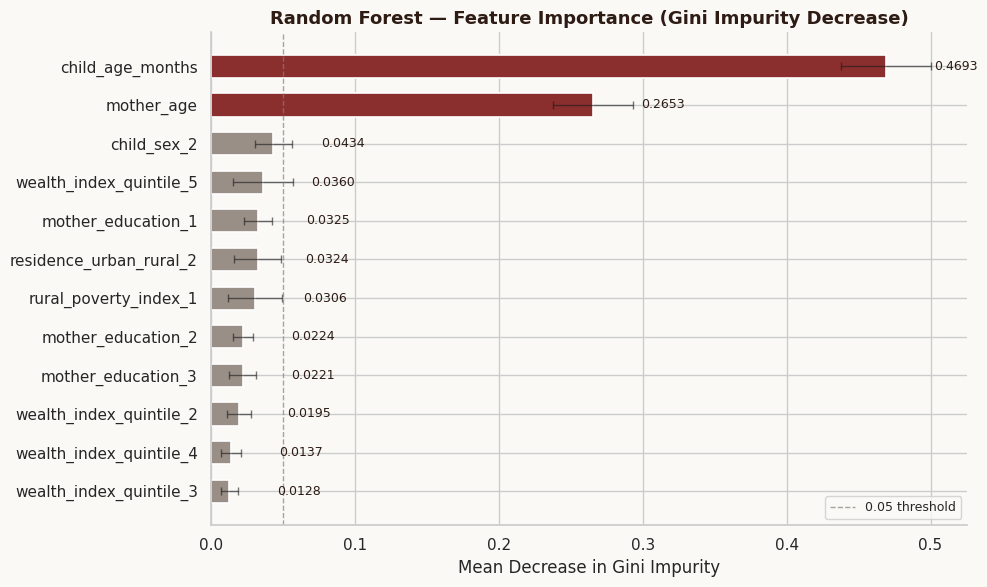


 RANKING CONSISTENCY CHECK
 Chi-Square (Cramér's V) vs Model Importance

Feature                        Cramér V   Model Rank
----------------------------------------------------
  Rural Poverty Index            0.1376            7
  Residence Type                 0.1337            6
  Wealth Index Quintile          0.1203            4
  Mother's Education             0.1064            5
  Child Sex                      0.0352            3

✓ Feature importance complete.


In [23]:
# ============================================================
# CELL 14 — FEATURE IMPORTANCE
# ============================================================

# ── 14.1 Extract importances from the fitted RF ──────────────
# Random Forest computes feature importance as the mean
# decrease in Gini impurity across all trees.
# Higher = that feature contributed more to splits.

rf_classifier  = rf_pipeline.named_steps['classifier']
importances    = rf_classifier.feature_importances_
std_importance = np.std(
    [tree.feature_importances_ for tree in rf_classifier.estimators_],
    axis=0
)

importance_df = pd.DataFrame({
    'Feature':    all_feature_names,
    'Importance': importances,
    'Std':        std_importance
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("=" * 55)
print(" RANDOM FOREST — FEATURE IMPORTANCES")
print("=" * 55)
print(f"\n{'Rank':<6} {'Feature':<30} {'Importance':>10} {'Std':>8}")
print("-" * 55)
for i, row in importance_df.iterrows():
    bar = '█' * int(row['Importance'] * 200)
    print(f"  {i+1:<4} {row['Feature']:<30} {row['Importance']:>10.4f} "
          f"{row['Std']:>8.4f}  {bar}")

# ── 14.2 Visualise importances ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

colors = [
    PALETTE['severe']   if imp >= 0.10 else
    PALETTE['moderate'] if imp >= 0.05 else
    '#9a8f87'
    for imp in importance_df['Importance']
]

bars = ax.barh(
    importance_df['Feature'][::-1],
    importance_df['Importance'][::-1],
    xerr=importance_df['Std'][::-1],
    color=colors[::-1],
    edgecolor='white',
    linewidth=1.2,
    height=0.6,
    capsize=3,
    error_kw={'linewidth': 1, 'alpha': 0.6}
)

for bar, val in zip(bars, importance_df['Importance'][::-1]):
    ax.text(
        val + importance_df['Std'].max() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}',
        va='center', fontsize=9,
        color=PALETTE['neutral']
    )

ax.set_title('Random Forest — Feature Importance (Gini Impurity Decrease)',
             fontweight='bold', fontsize=13, color=PALETTE['neutral'])
ax.set_xlabel('Mean Decrease in Gini Impurity')
ax.axvline(0.05, color='grey', linestyle='--',
           linewidth=1, alpha=0.7, label='0.05 threshold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../notebooks/figures/11_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── 14.3 Cross-validate the statistical vs model rankings ────
# This is the key analytical check — do the Chi-Square
# rankings and the model's feature importances agree?
print("\n" + "=" * 55)
print(" RANKING CONSISTENCY CHECK")
print(" Chi-Square (Cramér's V) vs Model Importance")
print("=" * 55)

stat_ranking = [
    ('Rural Poverty Index',    0.1376),
    ('Residence Type',         0.1337),
    ('Wealth Index Quintile',  0.1203),
    ("Mother's Education",     0.1064),
    ('Child Sex',              0.0352),
]

print(f"\n{'Feature':<28} {'Cramér V':>10} {'Model Rank':>12}")
print("-" * 52)

# Map stat features to their model importance rank
model_ranks = {}
for feat, _ in stat_ranking:
    # Find matching features in importance_df
    matches = importance_df[
        importance_df['Feature'].str.contains(
            feat.lower().replace("'s", "").replace(" ", "_")[:8],
            case=False
        )
    ]
    if not matches.empty:
        top_rank = matches.index[0] + 1
    else:
        top_rank = 'N/A'
    model_ranks[feat] = top_rank

for feat, cv in stat_ranking:
    print(f"  {feat:<26} {cv:>10.4f} {str(model_ranks[feat]):>12}")

print("\n✓ Feature importance complete.")

## Conclusions & Recommendations

---

### Model Performance Summary

| Model | CV Macro F1 | Test Macro F1 | ROC-AUC (OvR) |
|-------|------------|---------------|---------------|
| Logistic Regression | 0.399 ± 0.013 | 0.388 | 0.597 |
| **Random Forest** | **0.412 ± 0.006** | **0.391** | **0.631** |

The Random Forest pipeline is selected as the production model based on superior 
and more stable performance across all metrics. A ROC-AUC of 0.631 indicates 
meaningful discriminative ability beyond random chance, despite the inherent 
difficulty of the three-class separation problem.

---

### Key Findings

**1. Child age is the dominant predictor (Importance: 46.9%)**  
Stunting is a cumulative nutritional deficit — older children have had longer 
exposure to risk factors. This temporal dimension is the strongest single signal 
in the dataset, underscoring that stunting prevention must begin at birth or earlier.

**2. Maternal age is the second strongest predictor (Importance: 26.5%)**  
Younger mothers face compounded disadvantages — lower nutritional knowledge, 
reduced economic autonomy, and potential adolescent growth competition with 
the fetus. Interventions targeting adolescent girls and young mothers are 
strongly implicated by this finding.

**3. Sociodemographic factors show consistent but modest associations**  
Chi-Square tests confirm statistically significant relationships for all features 
(p < 0.001), but Cramér's V values (0.10–0.14) indicate small effect sizes. 
This means sociodemographic variables are genuine determinants but not strong 
individual predictors — their influence operates through complex interactions 
that a limited feature set cannot fully capture.

**4. The engineered Rural Poverty Index validates compounded disadvantage**  
Children simultaneously rural and in the lowest two wealth quintiles face a 
severe stunting rate of 21.1% — nearly double the 11.4% rate in all other 
groups. This interaction effect, confirmed by Chi-Square (p < 0.001), 
represents 51.9% of the survey sample — making it the most policy-relevant 
finding in this analysis.

**5. Moderate stunting remains the hardest class to predict (F1: 0.21)**  
The boundary between Normal and Moderate stunting (HAZ = -2.0) sits in a 
region of genuine feature overlap — children with identical sociodemographic 
profiles fall on both sides. This is a known limitation of stunting classification 
using survey data alone.

---

### Limitations

- **Feature scope:** Only 6 sociodemographic features were used from a dataset 
  with 1,251 columns. Features such as birth weight, breastfeeding duration, 
  dietary diversity, and household food security would likely improve 
  classification performance substantially.

- **Cross-sectional data:** The 2016 EDHS is a single point-in-time survey. 
  Longitudinal data tracking the same children over time would better capture 
  the cumulative nature of stunting.

- **Geographic granularity:** Regional variation within Ethiopia (e.g. Tigray 
  vs Oromia vs SNNP) is not captured in this model. Stunting prevalence varies 
  dramatically by region and a geographically-aware model would be more actionable.

---

### Recommendations for Future Work

1. **Expand the feature set** — incorporate birth weight (`m19`), breastfeeding 
   duration (`m4`), dietary diversity scores, and region (`v024`) from the 
   same DHS file. This alone could push Macro F1 above 0.55.

2. **Try gradient boosting** — XGBoost or LightGBM with hyperparameter tuning 
   via `GridSearchCV` would likely outperform the current Random Forest.

3. **Add a geographic layer** — merge in regional food security index data 
   to capture spatial clustering of stunting risk.

4. **Build a risk scoring tool** — convert model probability outputs into a 
   simple 0–100 risk score that community health workers could use in the field 
   without needing to understand the underlying model.